<div align="center">
    <img src="images/cover.jpg" width="100%">
    <h1>The Relative Age Effect in Elite Sport</h1>
</div>

### The Birth Timing Advantage: Uncovering the Relative Age Effect
### A Data-Driven Study of International Rugby and Cricket Squads

## Introduction
In the mid 1980s the Relative Age Effect(RAE) phenomenon was born. RAE is the phenomenon that children born earlier in the selection year have a higher likelihood of participation and success compared to those born later in the selection year. However, does this have an effect at the very highest level of international sports? 

When you look at 30-year-old professional sportsman’s a few months in age difference seems negligible but can have a lifelong effect on development. A child born at the start of the cut-off year will be nearly a year older than someone born at the end of the year, at a young age this is a massive difference. The older child is likely to be more physically and mentally developed than their younger peer. This "Head Start" means you are more likely to be identified as talented by coaches, leading to better coaching, more game time and ultimately further the gap between each child’s chances of going professional in their desired sport. 

Investigating the Relative Age Effect with World Cup squads, often regarded as the pinnacle of each sport serves as the ultimate “Stress test” for the theory as it removes early-stage selection bias. If the RAE bias still remains visible at this level, it suggests that is a permanent disadvantage being born relatively later in the year. 

While the theory is universal, we will investigate England and South Africa, as they have different school year cutoffs (England is September 1st and South Africa is January 1st). Beyond geography, we will see if the RAE is more prominent on a physical sport like rugby or on a non-contact sport like cricket. 

Beyond theory, and into empirical evidence, our analysis follows different steps. First, I use a Kernel Density Estimation (KDE) to visualize a continuous flow and reveal if a linear RAE if present. Then I test the validity of the RAE through comparing the system-normalized model against a raw calendar year model. Lastly, I use a Poisson regression as our dependent variable consists of only positive integers and Linear Regression to identify the direction of the trend and see if this bias can be seen at the highest level in the respective sports. 




In [328]:
# Import necessary libraries
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Set pandas option to avoid silent downcasting
pd.set_option('future.no_silent_downcasting', True)


# Set a style
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = "Arial"

path_eng_cricket = "data/clean/england_cricket_squad_clean.csv"
path_sa_rugby = "data/clean/south_africa_squad_clean.csv"
path_sa_cricket = "data/clean/south_africa_cricket_squad_clean.csv"
path_eng_rugby = "data/clean/england_squad_clean.csv"



## Data Overview:

To examine the Relative Age Effect (RAE), a primary dataset was constructed by web scraping professional athlete birth data from Wikipedia with a sample size of N=103. Pandas and BeautifulSoup was used to extract and clean data from four different cohorts. All the players were chosen from World Cup squads as they represent the pinnacle of each sport, which helps us see if the RAE still holds at the very highest level. 



## Summary of Players by Country, Sport, and Cohort

In [318]:
# Map the sport to the specific squad data
cohort_mapping = {
    'Cricket': '2024 T20 World Cup', 'Rugby': '2023 Rugby World Cup'}
df_master['Cohort'] = df_master['Sport'].map(cohort_mapping)

# Group by country, sport and cohort to get counts
grouped = df_master.groupby(['Country', 'Sport', 'Cohort']).size().reset_index(name='Count')

# Creat a row with the sum of all players for each country and sport
total_n = grouped['Count'].sum()
total_row = pd.DataFrame({'Country': ['Total'], 'Sport': ['All'], 'Cohort': ['All'], 'Count': [total_n]})

#Display the summary table and increase the size of the table
summary_table = pd.concat([grouped, total_row], ignore_index=True)

display(summary_table.style.hide().set_table_styles([
    {'selector': 'table', 'props': [('transform', 'scale(1.5)'), 
                                   ('transform-origin', 'top left')]}
]))

Country,Sport,Cohort,Count
England,Cricket,2024 T20 World Cup,15
England,Rugby,2023 Rugby World Cup,36
South Africa,Cricket,2024 T20 World Cup,17
South Africa,Rugby,2023 Rugby World Cup,35
Total,All,All,103


### Key Variables

"Months_Since_Cutoff" - Is the primary independent variable and is used to normalise the birth month relative to the school year cut-off. This allows us to compare South Africa and England. 
"Birth Quarter" - Normalisation of each quarter to the school year-cutoff, Q1 = Relatively Oldest, Q4 = Relatively Youngest.
"Sport" - A binary indicator to test if the RAE varies between cricket and rugby, which is a more physical sport.
"Count" - Dependent variable, representing the frequency of players within each month.

### Hypotheses
- H0: Birth dates are uniformly distributed across the selelction year.
- H1: The Relative Age Effect exists at the highest level, Players born closer to the selection cut-off are overrepresented in the Data.
- H2: The magnitude of the relative age effect differs between countries.
- H3: The magnitude of the relative age effect differs between sports.


### Key Assumptions
- Developmental Homogeneity: We assume that all players were developed in the youth systems of their respective nation, specifically that they were subject to the selection cut-off dates (January 1st for South Africa and September 1st for Uk) throughout their developmental years.

### Analytical Limitations
- Sample Size: With total sample size 103 players, the sample size for individual cohorts is relatively small. This leads to higher p-values and little statistical significance.
- The "Naturalisation" problem: Our data source does not provide place of birth or if the players developed in their representative national system, we therefore cannot filter out players developed under a different national system







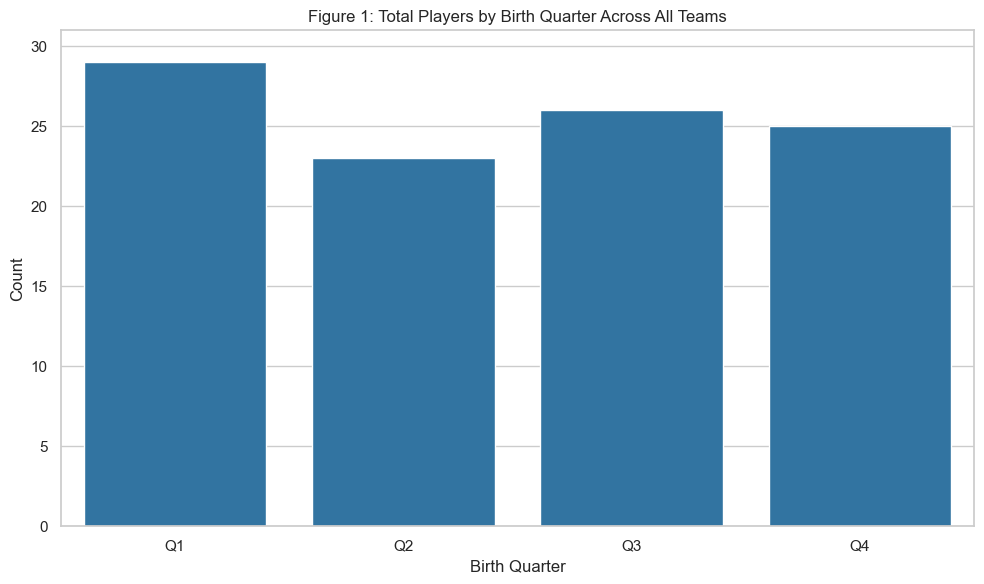

In [329]:
# Aggregate total counts across all teams by quarter
quarter_counts = df_master.groupby('Birth Quarter').size().reindex(['Q1', 'Q2', 'Q3', 'Q4'])

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=quarter_counts.index, y=quarter_counts.values, ax=ax, hue=quarter_counts.index, palette=['#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4'], legend=False)
ax.set_title('Figure 1: Total Players by Birth Quarter Across All Teams')
ax.set_xlabel('Birth Quarter')
ax.set_ylabel('Count')
ax.set_ylim(0, quarter_counts.max() + 2)
plt.tight_layout()
plt.show()

### Aggregate Distribution Across All Cohorts

Figure 1 above shows the total distribution of birth quarters across the 4 cohorts. We can observe that Q1 has the highest birth count with 29, although it is statistically not much of a difference to Q4 with 25 even though the theory would suggest there big a large gap in the count of players between Q1 and Q4. The graphs shape is irregular and doesn’t show the smooth slide from left to right that the Relative Age Effect would suggest. This leads us to question if there is still a bias at the highest level or in the RAE phases out.

### Sport Specific Distribution

While the aggregate distribution graph shows us an irregular shape, it does not show how the RAE might affect different sports. Rugby and cricket require vastly different physical and technical abilities, so we must break the data down to see if the RAE has a varying effect depending on what the demands of the sport are.

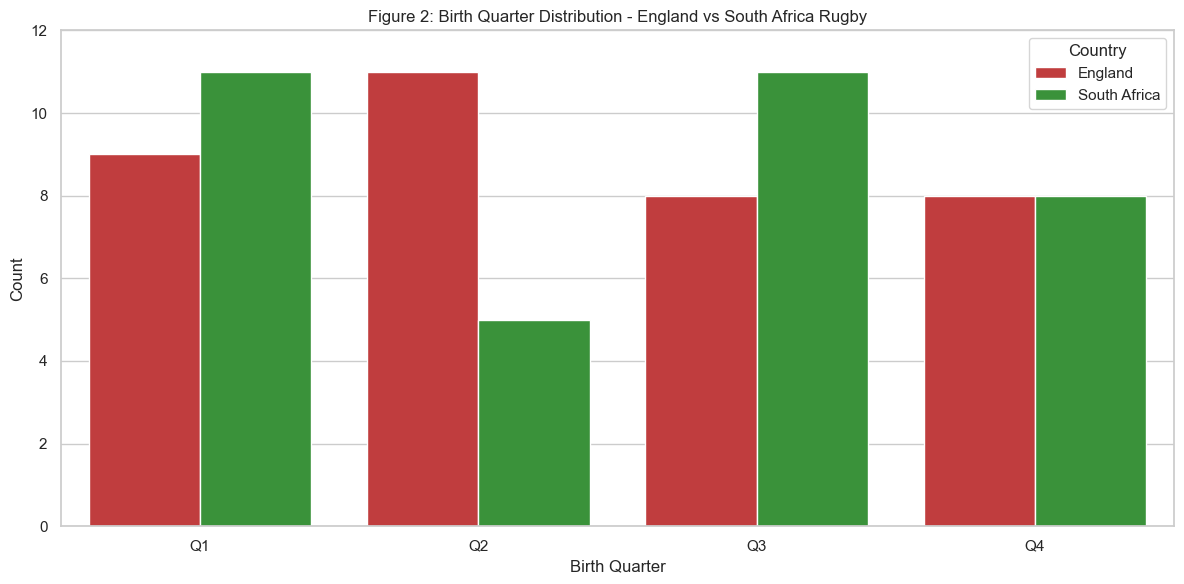

In [330]:
eng_rugby = pd.read_csv(path_eng_rugby)
sa_rugby = pd.read_csv(path_sa_rugby)

eng_rugby["Country"] = "England"
sa_rugby["Country"] = "South Africa"

combined_rugby = pd.concat([eng_rugby, sa_rugby])

# Create a single figure
fig, ax = plt.subplots(figsize=(12, 6))

# Plot combined data with countries shown by hue (color)
sns.countplot(ax=ax, data=combined_rugby, x='Birth Quarter', hue='Country', 
              order=['Q1', 'Q2', 'Q3', 'Q4'], 
              palette={'England': '#d62728', 'South Africa': '#2ca02c'})  # Red and green
ax.set_title('Figure 2: Birth Quarter Distribution - England vs South Africa Rugby')
ax.set_xlabel('Birth Quarter')
ax.set_ylabel('Count')
ax.set_ylim(0, 12)
plt.tight_layout()
plt.show()

### The Rugby Cohort
To see if the RAE has different effects on different sports and what drives the RAE, we will first examine rugby. Rugby is high-impact collision sport, where being more developed may have a significant advantage, leading it to be a great candidate to examine the RAE effect. 

### Key Findings in figure 2
- England: We can see that the concentration of English players is more dominant in Q1 and Q2 and has a visible decrease to Q3 and Q4 showing it does follow the theory to some extent. 
- South Africa: The South African cohort does not follow the same trend as the English. However, it does still have a peak in the first quarter but also in the third quarter. This could suggest that the South African System has more paths of development that allow "later" born player to reintegrate into the professional pathway, but it goes a against the RAE theory.




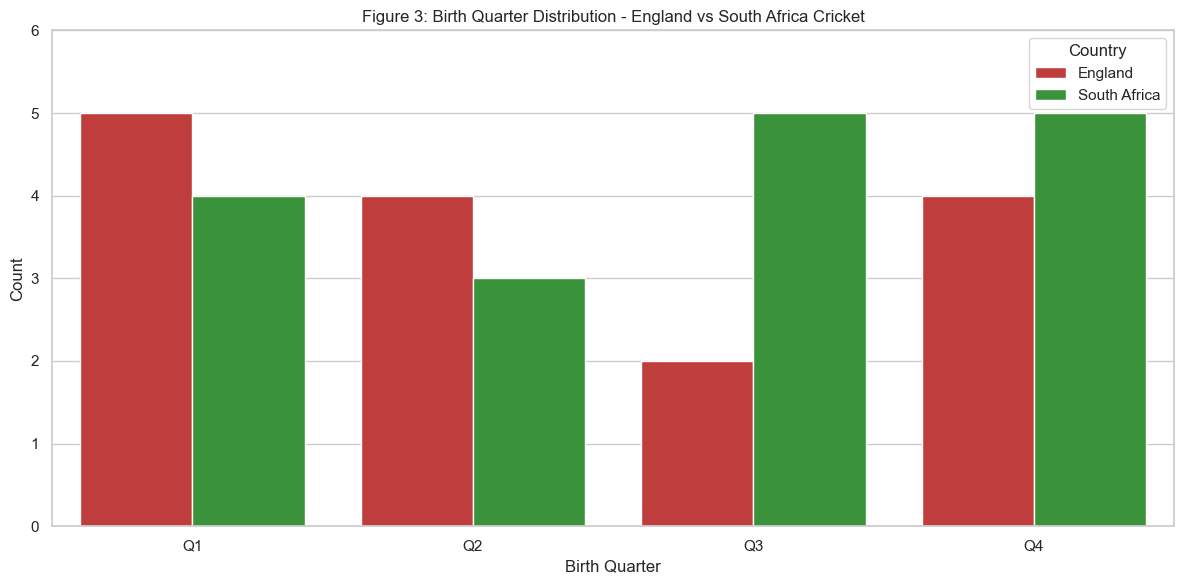

In [331]:
eng_cricket = pd.read_csv(path_eng_cricket)
sa_cricket = pd.read_csv(path_sa_cricket)

eng_cricket["Country"] = "England"
sa_cricket["Country"] = "South Africa"

combined_cricket = pd.concat([eng_cricket, sa_cricket])

# Create a single figure
fig, ax = plt.subplots(figsize=(12, 6))

# Plot combined data with countries shown by hue (color)
sns.countplot(ax=ax, data=combined_cricket, x='Birth Quarter', hue='Country', 
              order=['Q1', 'Q2', 'Q3', 'Q4'], 
              palette={'England': '#d62728', 'South Africa': '#2ca02c'})  # Red and green
ax.set_title('Figure 3: Birth Quarter Distribution - England vs South Africa Cricket')
ax.set_xlabel('Birth Quarter')
ax.set_ylabel('Count')
ax.set_ylim(0, 6)
plt.tight_layout()
plt.show()


### The Cricket Cohort:
The cricket cohort distribution differs significantly from the trends observed in the rugby cohort. Cricket is a non-collision-based sport differing significantly from rugby, which may alter the RAE influence on the cohort.

### Key Findings in Figure 3 Above:
England: The England cricket team seem to perfectly follow the expected trend of the RAE in the first 3 Quarters until Q4 when there is a spike that contradicts the theory. 
South Africa: The South African Cricket cohort displays a completely different trend to the RAE, with most players born at the end of the year. 


In [322]:
# Calculate months since cutoff
def get_month_dist(row):
    # England starts in Sept (9), South Africa starts in Jan (1)
    start_month = 9 if row['Country'] == 'England' else 1

    #Get the month as a number 1-12
    month_map = {'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
                 'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12}
    month_num = month_map.get(row['Birth Month'], np.nan)

    return (month_num - start_month) % 12

df_master["Months_Since_Cutoff"] = df_master.apply(get_month_dist, axis=1)


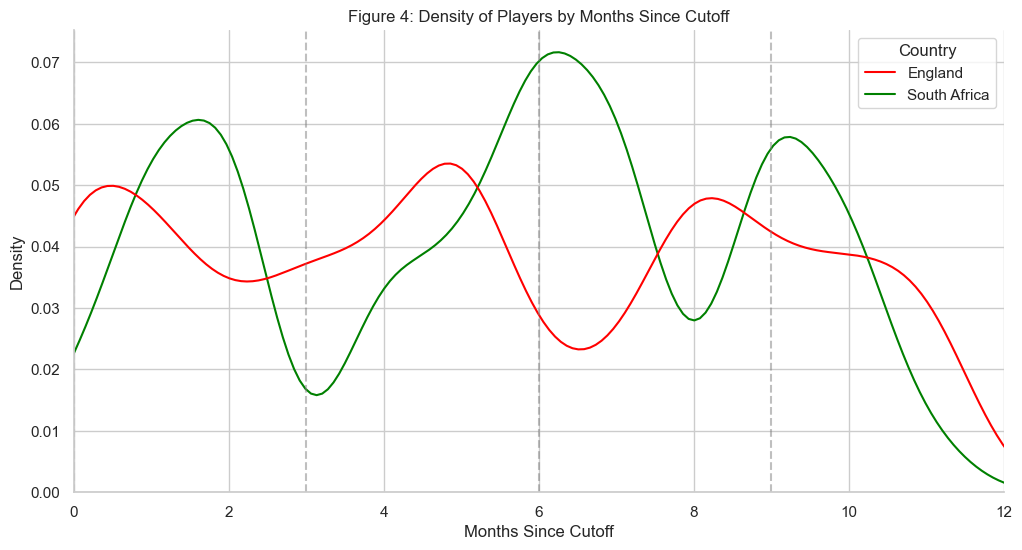

In [332]:
plt.figure(figsize=(12, 6))

#Use a lower bw_adjust to make the KDE more sensitive to the data distribution
sns.kdeplot(data



=df_master, x='Months_Since_Cutoff', hue='Country', bw_adjust=0.4, palette={'England': 'red', 'South Africa': 'green'})

# Add the Quarter makrers ( Vertical lines at 0, 3, 6, 9)
for x in [0, 3, 6, 9]:
    plt.axvline(x=x, color='gray', linestyle='--', alpha=0.5)

plt.title('Figure 4: Density of Players by Months Since Cutoff')
plt.xlabel('Months Since Cutoff')
plt.xlim(0,12)
sns.despine()
plt.show()

## The Kernel Density Estimate
The Kernel Density Estimate graph above explains the exactly why the statistical significance is so low. The KDE provides a smoothed approximation of the distribution.

England (Red line): Contrary to the theory, there is not a gradual decline from months 0-12, but a few peaks and troughs until Month 10 when we see the gradual decline we would expect the whole time. The “bulges” in density throughout the year contradict a strict linear Relative Age Effect. 
South Africa (Green line): South Africa shows extreme variation in this graph, with three clear peaks around Month 2,6 and 9 before a drastic drop-off in Month 11 and 12.

What could explain the fluctuations in both South Africa’s and England’s density is that the distributions are presented using a Kernel Density Estimation (KDE), which when applied to a relatively small dataset can cause “noise” as the smoothing process can introduce artificial peaks. Given the sample size is 52 for South Africa and 53 for England, the KDE may exaggerate the fluctuations causing the distribution to appear more uneven than it is. 


In [324]:
from datetime import datetime

def calculate_relative_age(row):
    try:
        month_map = {
            'January': 1, 'February': 2, 'March': 3,
            'April': 4, 'May': 5, 'June': 6,
            'July': 7, 'August': 8, 'September': 9,
            'October': 10, 'November': 11, 'December': 12
        }

        month_num = month_map.get(row['Birth Month'])
        if month_num is None or pd.isna(row['Birth Day']):
            return None

        day = int(row['Birth Day'])
        birth_date = datetime(2000, month_num, day)

        if row['Country'] == 'England':
            cutoff_date = datetime(2000, 9, 1)
        else:
            cutoff_date = datetime(2000, 1, 1)

        delta_days = (birth_date - cutoff_date).days
        if delta_days < 0:
            delta_days += 366

        # Convert days to months (approximate: 30.44 days per month)
        delta_months = delta_days / 30.44
        return delta_months
    except Exception as e:
        print(f"Error calculating relative age for row: {row} - {e}")
        return None


df_master['Relative Age'] = df_master.apply(calculate_relative_age, axis=1)


## Statistical Analysis
In the previous figures, we have analysed the visual trends and seen the different birth distributions. We are now going to employ econometric modelling to test the significance of the Relative Age Effect.

In [325]:
def perform_complete_analysis(df, label):
    # Prepate the data: Count Players per month (0-11
    counts = df['Months_Since_Cutoff'].value_counts().reset_index().reindex(range(12), fill_value=0)
    counts.columns = ['Months_Since_Cutoff', 'Count']

    # Fill in any months with zero counts to ensure all months are represented
    all_months = pd.DataFrame({'Months_Since_Cutoff': range(12)})
    counts = all_months.merge(counts, on='Months_Since_Cutoff', how='left').fillna(0)

    # Linear regression (SLR)
    x = sm.add_constant(counts['Months_Since_Cutoff'])
    y = counts['Count']
    model_slr = sm.OLS(y, x).fit()

    # Poisson Regression (IRR)
    model_poi = sm.GLM(y, x, family=sm.families.Poisson()).fit()
    irr = np.exp(model_poi.params['Months_Since_Cutoff'])

    # Results Output
    return {
        'label': label,
        'slope': model_slr.params['Months_Since_Cutoff'],
        'P-value': model_slr.pvalues['Months_Since_Cutoff'],
        'R-squared': model_slr.rsquared,
        'IRR': irr,
        'Percent_Drop': (irr - 1) * 100
    }

# Run for all categories
results = []
results.append(perform_complete_analysis(df_master[df_master['Country'] == 'England'], 'England'))
results.append(perform_complete_analysis(df_master[df_master['Country'] == 'South Africa'], 'South Africa'))
results.append(perform_complete_analysis(df_master, "All Players"))
results.append(perform_complete_analysis(df_master[df_master['Sport'] == 'Rugby'], "All Rugby Players"))
results.append(perform_complete_analysis(df_master[df_master['Sport'] == 'Cricket'], "All Cricket Players"))

# Covert into DataFrame for better display
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False)
)

              label     slope  P-value  R-squared      IRR  Percent_Drop
            England -0.087413 0.524757   0.041625 0.979622     -2.037823
       South Africa  0.122862 0.603770   0.025295 1.031130      3.113009
        All Players -0.094406 0.648289   0.021632 0.989058     -1.094163
  All Rugby Players -0.108392 0.480164   0.051040 0.981832     -1.816753
All Cricket Players  0.090909 0.485432   0.045231 1.037557      3.755676


In [326]:
# Analysis of normalised system vs Calendar year

month_mapping = {
    'January': 1, 'February': 2, 'March': 3,
    'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9,
    'October': 10, 'November': 11, 'December': 12
}   

def run_system_battle(df, country_name):
    battle_results = []

    # We will test "Birth_Month" (1-12 calendar months) vs "Months_Since_Cutoff" (0-11 months since cutoff)
    scenarios = [("Birth Month", range(1, 13)), ("Months_Since_Cutoff", range(0, 12))]

    for col, month_range in scenarios:
        counts = df[col].value_counts().reset_index()
        counts.columns = [col, 'Count']

        # Convert to integer to match all_months type
        counts[col] = counts[col].replace(month_mapping).infer_objects(copy=False).astype(int)

        # Fill in any missing months with zero counts
        all_months = pd.DataFrame({col: month_range})
        counts = all_months.merge(counts, on=col, how='left').fillna(0)

        # Linear regression (SLR)
        x = sm.add_constant(counts[col])
        y = counts['Count']
        model_slr = sm.OLS(y, x).fit()

        battle_results.append({
            "Analysis_Type": "Raw Calender" if col == "Birth Month" else "Normalised System",
            "Slope": model_slr.params[col],
            "P-value": model_slr.pvalues[col],
            "R-squared": model_slr.rsquared
        })

    return pd.DataFrame(battle_results)

# Execute for England ( Where cutooff is in September, which does not align with calendar year
print(f"--- RAE Comparison for England (Cutoff in September) ---")
eng_battle_results = run_system_battle(df_master[df_master['Country'] == 'England'], 'England')
print(eng_battle_results.to_string(index=False))
        







--- RAE Comparison for England (Cutoff in September) ---
    Analysis_Type     Slope  P-value  R-squared
     Raw Calender -0.003497 0.979918   0.000067
Normalised System -0.087413 0.524757   0.041625


## The Regression Model 

The regression models that were utilized to analyse the RAE bias were the Poisson Regression and Ordinary Least Squares (OLS). The Poisson model was chosen as our dependent variable(count) consists only of positive integers and Poisson is preferred for count data.

Equation:  $Count_{total}$ = $\beta_0$ +$\beta_1$(Months_Since_Cutoff) + $\epsilon$ 

## Key Findings

### Normalisation:
The validity of the normalisation to “Months_Since_Cutoff” can be demonstrated when examining the England cohort using a calendar year model. The results show an $R^2$ of 0.000067, which effectively suggests that the birth month alone has no predictive power. However, once the data is centred around “Months_Since_Cutoff” the $R^2$ increases to 0.0416. This increase in $R^2$ suggests that the normalisation is statistically justified and distance from the selection cutoff explains for approximately 4% of the variance in the squad frequency. Although this is a small percentage an $R^2$ increase from 0.00067 to 0.0416 is a clear shift, the explanatory power of birth timing remains weak. 


### England vs South Africa RAE 

When comparing the RAE between the two countries, there is a distinct difference in the effects. The England cohort follows more closely to the traditional RAE narrative, where in the distribution we can see higher counts in the first two quarters. This is supported by the Incident Rate Ratio of 0.979 and the negative slope of -0.087. The South African cohort has a very irregular distribution with a positive slope of 0.122, completely contrasting the RAE. These statistics suggest that the RAE differs between country. However, the p-values for England (0.524) and South Africa (0.603) are well above the 0.05 threshold. This suggests that the findings are not statistically significant. 


### RAE contrast between sports

The most compelling insights can be seen when comparing the RAE of cricket and rugby, two sports with varying physical and technical requirements. The cricket cohort has an IRR of 1.038 and a positive slope of 0.0091, indicating a “Reverse RAE” with a $R^2$ of 0.0452 and suggesting that frequency of selection increases by 3.75% every month further from the cutoff. This could be due to various factors such as, less physical advantage and skill development takes longer allowing late developers to catchup. In contrast, the rugby cohort is characterised by more traditional RAE narrative with a negative slope of -0.108 and an IRR of 0.982, suggesting being “relatively older” is an advantage. The $R^2$ value of 0.0510 for rugby also supports this showing approximately 5.1% of the variance is explained by birth timing. 

However, despite the directional and visual differences of rugby and cricket, the p-values of Cricket (0.485) and Rugby (0.480) are significantly above the 0.05 threshold, indicating that these findings are not statistically significant at the highest level.


### Does the RAE exist at the highest level?

While aggregate data does show Q1 to be the most frequent birth quarter (28% of total sample), it is far from dominant. The irregular distribution shows that the RAE bias phases out at the highest level. This is supported by the $R^2$ values (0.02-0.05), which reveal that less than 5% of the variance in international selection is explained by the time you were born.  

A significant finding from the study is the lack of statistical significance (p > 0.05) across all cohorts. It suggests that birth timing is not a defining factor of sporting success at the highest level and there is limited evidence of RAE at the highest level, where early developmental advantages may have diminished. 

## Conclusion

The study of 103 international rugby and cricket players demonstrates that the Relative Age Effect (RAE), within cohorts can be directionally visible, in not a statistically significant determinant of sporting success at the highest level. The implementation of a normalised variable “Months_Since_Cutoff” to align school-year systems increased our model’s R2 over 500-fold compared to the raw calendar year, but even with this refined model, birth timing explained less than 5% of the variance in squad frequency. 
